In [1]:
import pathlib

import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
l1g_path = pathlib.Path("/work/scratch-nopw2/wkjones/EUM_L1g/")

In [3]:
bt_11_00 = xr.open_mfdataset(
    sorted(list((l1g_path/"18").glob("*__temp_11_00um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [4]:
bt_11_00

<xarray.Dataset> Size: 30GB
Dimensions:       (time: 48, layer: 3, latitude: 3600, longitude: 7200)
Coordinates:
  * latitude      (latitude) float64 29kB 89.98 89.93 89.88 ... -89.93 -89.98
  * longitude     (longitude) float64 58kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time          (time) datetime64[ns] 384B 2024-08-18 ... 2024-08-18T23:30:00
Dimensions without coordinates: layer
Data variables:
    crs           (time) int32 192B 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    temp_11_00um  (time, layer, latitude, longitude) float64 30GB dask.array<chunksize=(1, 1, 900, 900), meta=np.ndarray>

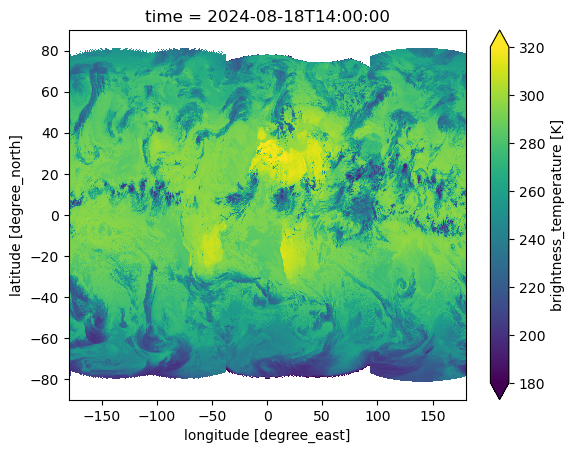

In [5]:
bt_11_00.temp_11_00um[28,0].plot(vmin=180, vmax=320)

In [6]:
bt_10_40 = xr.open_mfdataset(
    sorted(list((l1g_path/"18").glob("*__temp_10_40um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

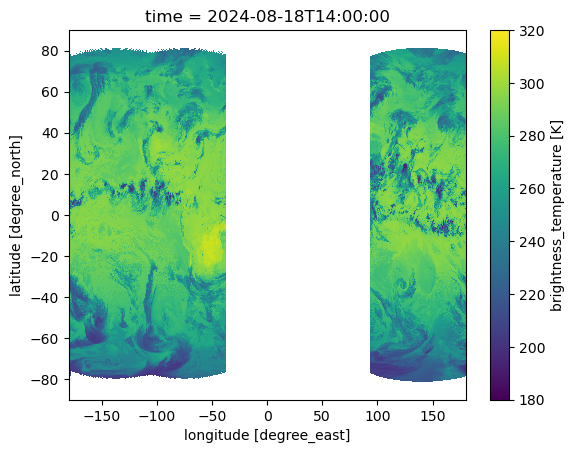

In [7]:
bt_10_40.temp_10_40um[28,0].plot(vmin=180, vmax=320)

In [8]:
bt_12_00 = xr.open_mfdataset(
    sorted(list((l1g_path/"18").glob("*__temp_12_00um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

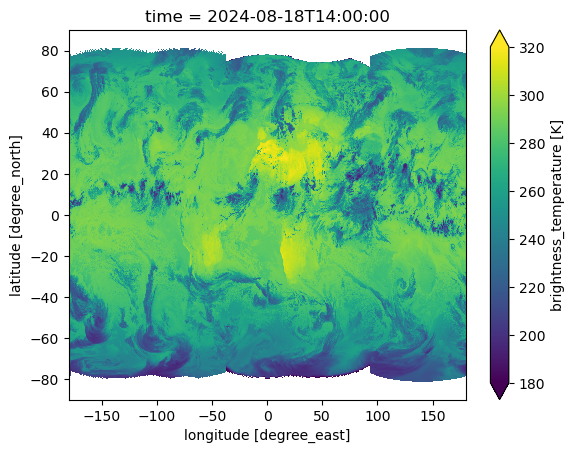

In [9]:
bt_12_00.temp_12_00um[28,0].plot(vmin=180, vmax=320)

In [10]:
bt_06_20 = xr.open_mfdataset(
    sorted(list((l1g_path/"18").glob("*__temp_06_20um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

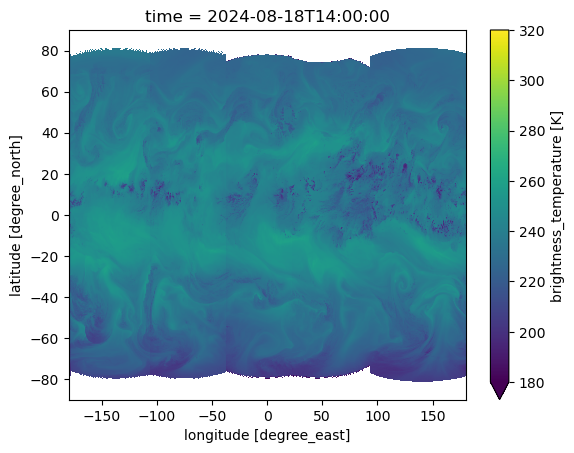

In [11]:
bt_06_20.temp_06_20um[28,0].plot(vmin=180, vmax=320)

In [12]:
bt_07_30 = xr.open_mfdataset(
    sorted(list((l1g_path/"18").glob("*__temp_07_30um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

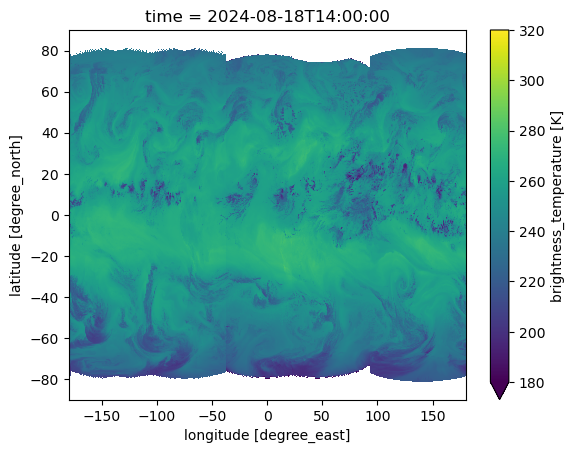

In [13]:
bt_07_30.temp_07_30um[28,0].plot(vmin=180, vmax=320)

In [14]:
bt_08_60 = xr.open_mfdataset(
    sorted(list((l1g_path/"18").glob("*__temp_08_60um__*.nc"))),
    combine="nested",
    concat_dim="time"
)

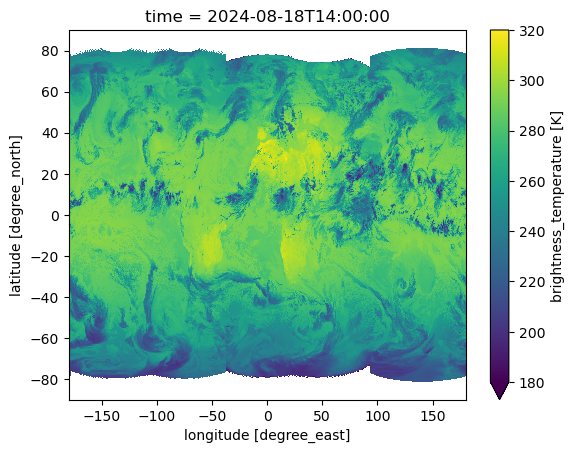

In [15]:
bt_08_60.temp_08_60um[28,0].plot(vmin=180, vmax=320)

In [16]:
bt = bt_11_00.temp_11_00um
wvd = bt_06_20.temp_06_20um - bt_07_30.temp_07_30um
swd = bt_08_60.temp_08_60um - bt_12_00.temp_12_00um

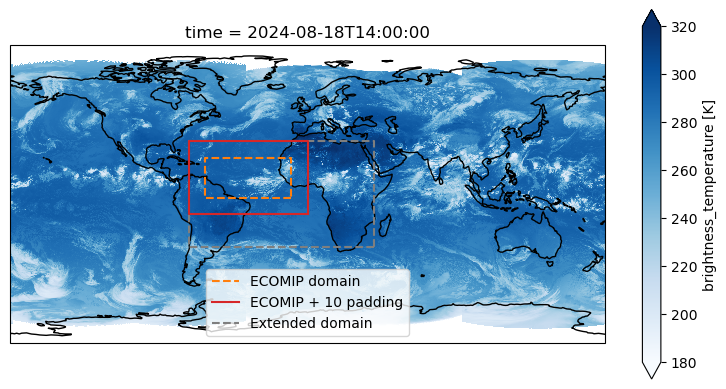

In [17]:
plt.figure(figsize=(9.6, 4.8))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
bt_11_00.temp_11_00um[28,0].plot(vmin=180, vmax=320, cmap="Blues")
ax.coastlines()

l_ext = ax.plot(
    [40, -72, -72, 40, 40],
    [-32, -32, 32, 32, -32],
    "C7--"
)
l_eco = ax.plot(
    [-10, -62, -62, -10, -10],
    [-2, -2, 22, 22, -2],
    "C1--"
)
l_pad = ax.plot(
    [0, -72, -72, 0, 0],
    [-12, -12, 32, 32, -12],
    "C3-"
)

plt.legend(
    [l_eco[0], l_pad[0], l_ext[0]],
    ["ECOMIP domain", "ECOMIP + 10 padding", "Extended domain"], 
    loc="lower center"
)

62W to 10W and from 22N to 2S + 10 degree pad

In [17]:
bt = bt.sel(latitude=slice(32, -12), longitude=slice(-72, 0), layer=0)
wvd = wvd.sel(latitude=slice(32, -12), longitude=slice(-72, 0), layer=0)
swd = swd.sel(latitude=slice(32, -12), longitude=slice(-72, 0), layer=0)

In [18]:
bt = bt.compute()
wvd = wvd.compute()
swd = swd.compute()

KeyboardInterrupt: 

In [ ]:
from tobac_flow.flow import create_flow
flow = create_flow(
    bt, model="Farneback", vr_steps=1, smoothing_passes=1, interp_method="linear"
)

In [34]:
flow

In [38]:
bt = bt.rename(time="t")
wvd = wvd.rename(time="t")
swd = swd.rename(time="t")

In [35]:
wvd_threshold = 0.25
bt_threshold = 0.25
overlap = 0.5
absolute_overlap = 1
subsegment_shrink = 0.0
min_length = 2

In [39]:
from tobac_flow.detection import detect_cores
core_labels = detect_cores(
    flow,
    bt,
    wvd,
    swd,
    wvd_threshold=wvd_threshold,
    bt_threshold=bt_threshold,
    overlap=overlap,
    absolute_overlap=absolute_overlap,
    subsegment_shrink=subsegment_shrink,
    min_length=min_length,
    use_wvd=False,
)

BT growth above threshold: area = 137692
Detected markers: area = 98738
Initial core count: 3572
Core labels meeting length threshold: 335
Core labels meeting WVD threshold: 1194
Core labels meeting cooling rate threshold: 121


In [40]:
# Detect anvil regions
upper_threshold = -5
lower_threshold = -10
erode_distance = 2

In [41]:
from tobac_flow.detection import get_anvil_markers
anvil_markers = get_anvil_markers(
    flow,
    wvd - swd,
    threshold=upper_threshold,
    overlap=overlap,
    absolute_overlap=absolute_overlap,
    subsegment_shrink=subsegment_shrink,
    min_length=min_length,
)

In [42]:
from tobac_flow.detection import detect_anvils
thick_anvil_labels = detect_anvils(
    flow,
    wvd - swd,
    markers=anvil_markers,
    upper_threshold=upper_threshold,
    lower_threshold=lower_threshold,
    erode_distance=erode_distance,
    min_length=min_length,
)

In [43]:
from tobac_flow.detection import relabel_anvils
thick_anvil_labels = relabel_anvils(
    flow,
    thick_anvil_labels,
    markers=anvil_markers,
    overlap=overlap,
    absolute_overlap=absolute_overlap,
    min_length=min_length,
)

In [44]:
thin_anvil_labels = detect_anvils(
    flow,
    wvd + swd,
    markers=thick_anvil_labels,
    upper_threshold=upper_threshold + 5,
    lower_threshold=lower_threshold + 5,
    erode_distance=erode_distance,
    min_length=min_length,
)

In [46]:
output_ds = xr.Dataset(
    coords=bt.coords,
)

In [50]:
core_labels

<xarray.DataArray 'core_label' (t: 48, latitude: 880, longitude: 1440)> Size: 243MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=int32)
Coordinates:
  * latitude   (latitude) float64 7kB 31.98 31.93 31.88 ... -11.88 -11.93 -11.98
  * longitude  (longitude) float64 12kB -71.98 -71.92 -71.88 ... -0.075 -0.025
  * t          (t) datetime64[ns] 384B 2024-08-18 ... 2024-08-18T23:30:00
Attributes:
    nickname:               IR Longwave Window Band
    central_wavelength_um:  11.0
    long_name:              Labels of detected core regions
    units:                  
    cell_measures:          area: area

In [51]:
output_ds["core_label"] = core_labels
output_ds["thick_anvil_label"] = thick_anvil_labels
output_ds["thin_anvil_label"] = thin_anvil_labels

In [53]:
output_ds = output_ds.rename(t="time")

In [54]:
output_ds.to_netcdf(l1g_path/"detected_dccs_L1g_S20240818_000000_E20240819_0000.nc")

In [55]:
xr.open_dataset(
    l1g_path/"detected_dccs_L1g_S20240818_000000_E20240819_0000.nc"
)

<xarray.Dataset> Size: 730MB
Dimensions:            (latitude: 880, longitude: 1440, time: 48)
Coordinates:
  * latitude           (latitude) float64 7kB 31.98 31.93 ... -11.93 -11.98
  * longitude          (longitude) float64 12kB -71.98 -71.92 ... -0.075 -0.025
  * time               (time) datetime64[ns] 384B 2024-08-18 ... 2024-08-18T2...
Data variables:
    core_label         (time, latitude, longitude) int32 243MB ...
    thick_anvil_label  (time, latitude, longitude) int32 243MB ...
    thin_anvil_label   (time, latitude, longitude) int32 243MB ...